# Importo le librerie necessarie


In [34]:
from re import match

from IPython.display  import display
from pymongo import MongoClient
import matplotlib.pyplot as plt
import pandas as pd

# Attivazione della connessione con MongoDB

In [35]:
# Chiamo il client
client = MongoClient("mongodb://localhost:27017/")

#Acquisisco il DB
db = client["KeybladeDB"]

#Prendo in esempio il dataset videogames_2016
videogames_2016 = db["videogames_2016"]
videogames_2024 = db["videogames_2024"]

# Caricamento dei dati dal dataset MongoDB

In [36]:
# Carica i dati dal database
df_2016 = pd.DataFrame(list(videogames_2016.find()))
df_2024 = pd.DataFrame(list(videogames_2024.find()))

# Controlla i nomi delle colonne
print(df_2016.columns)
print(df_2024.columns)

Index(['_id', 'Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher',
       'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales',
       'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer',
       'Rating'],
      dtype='object')
Index(['_id', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_date', 'last_update'],
      dtype='object')


# Grafico che mette a confronto le vendite globali del dataset del 2016 con quelle del dataset del 2024

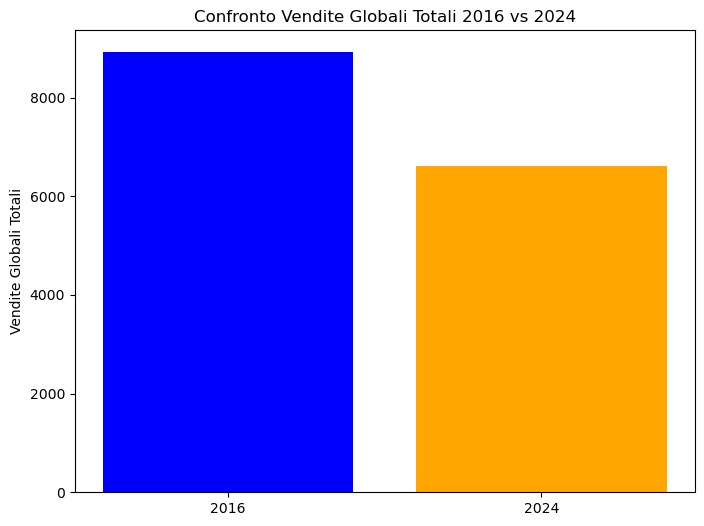

In [37]:
# Calcolo vendite totali per ciascun anno
total_sales_2016 = df_2016['Global_Sales'].sum()
total_sales_2024 = df_2024['total_sales'].sum()

# Dati e etichette
years = ['2016', '2024']
total_sales = [total_sales_2016, total_sales_2024]

# Grafico
plt.figure(figsize=(8,6))
plt.bar(years, total_sales, color=['blue', 'orange'])
plt.ylabel('Vendite Globali Totali')
plt.title('Confronto Vendite Globali Totali 2016 vs 2024')
plt.show()


# Query per la visualizzazione di giochi per rating (2016)

In [38]:
#Visualizzo i rating distinti presenti nel dataset videogames_2016
ratings=videogames_2016.distinct("Rating")

#creo un dizionario per la lista dei nomi per ciascun rating
rating_list={}

# Per ogni rating eseguo aggregazione
for rating in ratings:
    pipeline = [
        {"$match": {"Rating": rating}},
        {"$project": {"Name": 1, "Platform": 1, "_id": 0}}
    ]
    games = videogames_2016.aggregate(pipeline)
    games_df = pd.DataFrame(list(games))
    rating_list[rating] = games_df

# Visualizzazione dei risultati
for rating, games_df in rating_list.items():
    print(f"Giochi con rating {rating}:")
    display(games_df)
    print("\n")


Giochi con rating AO:


,Name,Platform
0,Grand Theft Auto: San Andreas,XB




Giochi con rating E:


,Name,Platform
0,Wii Sports,Wii
1,Mario Kart Wii,Wii
2,Wii Sports Resort,Wii
3,New Super Mario Bros.,DS
4,Wii Play,Wii
...,...,...
3989,Worms 2,PC
3990,Planet Monsters,GBA
3991,Bust-A-Move 3000,GC
3992,Mega Brain Boost,DS




Giochi con rating E10+:


...

,Name,Platform
0,Grand Theft Auto V,PS3
1,Grand Theft Auto: San Andreas,PS2
2,Grand Theft Auto V,X360
3,Grand Theft Auto: Vice City,PS2
4,Call of Duty: Modern Warfare 3,X360
...,...,...
1558,Xblaze: Lost Memories,PSV
1559,Metal Gear Solid HD Edition,X360
1560,Metal Gear Solid V: The Definitive Experience,XOne
1561,Mortal Kombat: Deadly Alliance,GBA




Giochi con rating RP:


,Name,Platform
0,Super Mario Bros.,NES
1,Pokemon Red/Pokemon Blue,GB
2,Tetris,GB
3,Duck Hunt,NES
4,Nintendogs,DS
...,...,...
6765,Samurai Warriors: Sanada Maru,PS3
6766,LMA Manager 2007,X360
6767,Haitaka no Psychedelica,PSV
6768,Spirits & Spells,GBA




Giochi con rating T:


,Name,Platform
0,Super Smash Bros. Brawl,Wii
1,Final Fantasy VII,PS
2,Gran Turismo 2,PS
3,Final Fantasy X,PS2
4,The Sims 3,PC
...,...,...
2956,Super Robot Taisen: Original Generation,GBA
2957,End of Nations,PC
2958,Outdoors Unleashed: Africa 3D,3DS
2959,Breach,PC


# Query per la visualizzazione delle vendite totali dei giochi in base al Developer (Video giochi 2016)

In [39]:
# Recupero dei developer distinti
developers = videogames_2016.distinct("Developer")

# Lista per raccogliere i risultati
rows = []

# Ciclo sui developer
for developer in developers:
    if developer == "Unknown":
        # Visualizza giochi singoli per Unknown
        pipeline = [
            {"$match": {"Developer": "Unknown"}},
            {"$project": {"Developer": 1,"Global_Sales": 1, "_id": 0}}
        ]
        result = list(videogames_2016.aggregate(pipeline))
        rows.extend(result)
    else:
        # Somma le vendite per gli altri developer
        pipeline = [
            {"$match": {"Developer": developer}},
            {"$group": {
                "_id": "$Developer",
                "Global_Sales": {"$sum": "$Global_Sales"}
            }}
        ]
        result = list(videogames_2016.aggregate(pipeline))
        if result:
            rows.append({"Developer": developer, "Global_Sales": result[0]["Global_Sales"]})
        else:
            rows.append({"Developer": developer,"Global_Sales": 0})

# Creazione del DataFrame
sales_df = pd.DataFrame(rows)
# Ordinamento per Global_Sales
sales_df = sales_df.sort_values(by="Global_Sales", ascending=False)

# Visualizzazione
display(sales_df)

,Developer,Global_Sales
1020,Nintendo,531.71
449,EA Sports,175.38
431,EA Canada,142.32
1539,Ubisoft,132.54
1220,Rockstar North,119.47
...,...,...
7962,Unknown,0.01
7961,Unknown,0.01
7960,Unknown,0.01
7959,Unknown,0.01


# Query per la visualizzazione delle vendite totali dei giochi in base al Developer (Video giochi 2024)

In [40]:
# Recupero dei developer distinti
developers = videogames_2024.distinct("developer")

# Lista per raccogliere i risultati
rows = []

# Ciclo sui developer
for developer in developers:
    if developer == "Unknown":
        # Visualizza giochi singoli per Unknown
        pipeline = [
            {"$match": {"developer": "Unknown"}},
            {"$project": {"developer": 1, "total_sales": 1, "_id": 0}}
        ]
        result = list(videogames_2024.aggregate(pipeline))
        rows.extend(result)
    else:
        # Somma le vendite per gli altri developer
        pipeline = [
            {"$match": {"developer": developer}},
            {"$group": {
                "_id": "$developer",
                "total_sales": {"$sum": "$total_sales"}
            }}
        ]
        result = list(videogames_2024.aggregate(pipeline))
        if result:
            rows.append({"developer": developer, "total_sales": result[0]["total_sales"]})
        else:
            rows.append({"developer": developer, "total_sales": 0})

# Creazione del DataFrame
sales_df = pd.DataFrame(rows)
# Ordinamento per total_sales
sales_df = sales_df.sort_values(by="total_sales", ascending=False)

# Visualizzazione
display(sales_df)


,developer,total_sales
2251,EA Canada,275.56
2269,EA Tiburon,178.33
7945,Ubisoft Montreal,172.96
7828,Treyarch,150.19
7816,Traveller's Tales,149.55
...,...,...
5231,Nibris,0.00
5233,Nicely Crafted,0.00
5234,Nichibutsu,0.00
5235,Nick Metnik,0.00


# Query che permette di visualizzare per ogni singolo videogioco, il numero totale di copie vendute in ogni continente (Dataset del 2016)

In [41]:
# Pipeline: visualizza tutti i giochi con dettagli di vendita
pipeline = [
    {"$project": {
        "_id": 0,
        "Developer": 1,
        "Global_Sales": 1,
        "NA_Sales": 1,
        "EU_Sales": 1,
        "JP_Sales": 1,
        "Other_Sales": 1
    }},
    {"$sort": {"Global_Sales": -1}}
]#Inserendo il -1 nell'operazione di sort, i risultati vengono ordinati in ordine decrescente in base alle vendite globali

# Esecuzione della pipeline
result = list(videogames_2016.aggregate(pipeline))
# Conversione in DataFrame
sales_df = pd.DataFrame(result)

# Visualizzazione
display(sales_df)


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Developer
0,41.36,28.96,3.77,8.45,82.53,Nintendo
1,29.08,3.58,6.81,0.77,40.24,Unknown
2,15.68,12.76,3.79,3.29,35.52,Nintendo
3,15.61,10.93,3.28,2.95,32.77,Nintendo
4,11.27,8.89,10.22,1.00,31.37,Unknown
...,...,...,...,...,...,...
16712,0.00,0.00,0.01,0.00,0.01,Unknown
16713,0.00,0.01,0.00,0.00,0.01,Unknown
16714,0.00,0.00,0.01,0.00,0.01,Unknown
16715,0.01,0.00,0.00,0.00,0.01,Unknown


# Query che permette di visualizzare per ogni singolo videogioco, il numero totale di copie vendute in ogni continente (Dataset del 2024)

In [42]:
# Pipeline: visualizza tutti i giochi con dettagli di vendita
pipeline = [
    {"$project": {
        "_id": 0,
        "developer": 1,
        "total_sales": 1,
        "na_sales": 1,
        "pal_sales": 1,
        "jp_sales": 1,
        "other_sales": 1
    }},
    {"$sort": {"total_sales": -1}}
]#Inserendo il -1 nell'operazione di sort, i risultati vengono ordinati in ordine decrescente in base alle vendite globali

# Esecuzione della pipeline
result = list(videogames_2024.aggregate(pipeline))
# Conversione in DataFrame
sales_df = pd.DataFrame(result)

# Visualizzazione
display(sales_df)

,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,Rockstar North,20.32,6.37,0.99,9.85,3.12
1,Rockstar North,19.39,6.06,0.60,9.71,3.02
2,Rockstar North,16.15,8.41,0.47,5.49,1.78
3,Rockstar North,15.86,9.06,0.06,5.33,1.42
4,Treyarch,15.09,6.18,0.41,6.05,2.44
...,...,...,...,...,...,...
64011,Arc System Works,0.00,0.00,0.00,0.00,0.00
64012,Nippon Ichi Software,0.00,0.00,0.00,0.00,0.00
64013,Nippon Ichi Software,0.00,0.00,0.00,0.00,0.00
64014,Otomate,0.00,0.00,0.00,0.00,0.00


# Query che permette di visualizzare il Publisher che ha ottenuto un Critic_Score maggiore per il dataset del 2016

In [43]:
# Estrai i campi necessari dal dataset 2016
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {"Critic_Score": {"$ne": None}},  # Esclude i giochi senza voto
    {"_id": 0, "Publisher": 1, "Critic_Score": 1}
)))

# Rimuovi eventuali NaN
df_2016_scores = df_2016_scores.dropna(subset=['Critic_Score'])

# Converte i punteggi su scala 10
df_2016_scores['Critic_Score'] = df_2016_scores['Critic_Score'] / 10

# Calcola la media dei Critic_Score per Publisher
publisher_avg_score = df_2016_scores.groupby('Publisher')['Critic_Score'].mean().reset_index()

# Trova il Publisher con la media più alta
top_publisher = publisher_avg_score.sort_values(by='Critic_Score', ascending=False).head(1)

# Visualizza il risultato
print(top_publisher)


    Publisher  Critic_Score
536     Valve           9.5


# Query che permette di visualizzare il Publisher che ha ottenuto un Critic_Score maggiore per il dataset del 2024

In [44]:
# Estrai i campi necessari dal dataset 2016
df_2024_scores = pd.DataFrame(list(videogames_2024.find(
    {"critic_score": {"$ne": None}},  # Esclude i giochi senza voto
    {"_id": 0, "publisher": 1, "critic_score": 1}
)))

# Rimuovi eventuali NaN (in caso di critic_score vuoti)
df_2024_scores = df_2024_scores.dropna(subset=['critic_score'])

# Calcola la media dei Critic_Score per Publisher
publisher_avg_score = df_2024_scores.groupby('publisher')['critic_score'].mean().reset_index()

# Trova il Publisher con la media più alta
top_publisher = publisher_avg_score.sort_values(by='critic_score', ascending=False).head(1)

# Visualizza il risultato
print(top_publisher)


      publisher  critic_score
362  Bimboosoft           9.4


# Query che prende in input un Developer e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2016

In [45]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "Critic_Score": {"$ne": None},
        "Developer": {"$ne": None}
    },
    {"_id": 0, "Developer": 1, "Critic_Score": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['Critic_Score'] = df_2016_scores['Critic_Score'] / 10

    # Calcolo media per ogni Developer
    avg_scores_by_developer = df_2016_scores.groupby("Developer")['Critic_Score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_developer = avg_scores_by_developer.sort_values(by="Critic_Score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_developer)
else:
    print("Nessun dato valido trovato nel dataset 2016.")


                               Developer  Critic_Score
757           Irrational Games, 2K Marin      9.600000
399           Digital Extremes, 2K Marin      9.400000
257                      Bungie Software      9.366667
364           DMA Design, Rockstar North      9.300000
1220                      Rockstar North      9.285714
...                                  ...           ...
297   Classic Media Distribution Limited      0.000000
1448   Targem Games, TopWare Interactive      0.000000
742           Interworks Unlimited, Inc.      0.000000
1163    RED Entertainment, Compile Heart      0.000000
993                         Navarre Corp      0.000000

[1697 rows x 2 columns]


# Query che prende in input un Developer e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2024

In [46]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2024_scores = pd.DataFrame(list(videogames_2024.find(
    {
        "critic_score": {"$ne": None},
        "developer": {"$ne": None}
    },
    {"_id": 0, "developer": 1, "critic_score": 1}
)))

# Se ci sono risultati
if not df_2024_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2024_scores['critic_score'] = df_2024_scores['critic_score']

    # Calcolo media per ogni Developer
    avg_scores_by_developer = df_2024_scores.groupby("developer")['critic_score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_developer = avg_scores_by_developer.sort_values(by="critic_score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_developer)
else:
    print("Nessun dato valido trovato nel dataset 2024.")


                              developer  critic_score
8044                           VGChartz          10.0
7121                   Starfire Studios          10.0
2658  Flagship Co., Ltd. / Nintendo EAD           9.6
48             2K Australia / 2K Boston           9.6
6143                             Raster           9.3
...                                 ...           ...
3254                          Hackberry           0.0
3253                         Hack Berry           0.0
3252                    Hachikou Shouji           0.0
3251                         HaccaWorks           0.0
8861                               zio3           0.0

[8862 rows x 2 columns]


# Query che prende in input un Publisher e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2016

In [47]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "Critic_Score": {"$ne": None},
        "Publisher": {"$ne": None}
    },
    {"_id": 0, "Publisher": 1, "Critic_Score": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['Critic_Score'] = df_2016_scores['Critic_Score'] / 10

    # Calcolo media per ogni Developer
    avg_scores_by_publisher = df_2016_scores.groupby("Publisher")['Critic_Score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_publisher = avg_scores_by_publisher.sort_values(by="Critic_Score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_publisher)
else:
    print("Nessun dato valido trovato nel dataset 2016.")


                  Publisher  Critic_Score
536                   Valve           9.5
537          Valve Software           9.3
3                    2D Boy           9.0
205  Graphsim Entertainment           9.0
371             Number None           9.0
..                      ...           ...
154    Excalibur Publishing           0.0
155         Experience Inc.           0.0
366               Nitroplus           0.0
365          Nippon Telenet           0.0
580            responDESIGN           0.0

[581 rows x 2 columns]


# Query che prende in input un Publisher e restituisce la media del Critic_Score effettuata dai critici per il dataset del 2024

In [48]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2024_scores = pd.DataFrame(list(videogames_2024.find(
    {
        "critic_score": {"$ne": None},
        "publisher": {"$ne": None}
    },
    {"_id": 0, "publisher": 1, "critic_score": 1}
)))

# Se ci sono risultati
if not df_2024_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2024_scores['critic_score'] = df_2024_scores['critic_score']

    # Calcolo media per ogni Developer
    avg_scores_by_publisher = df_2024_scores.groupby("publisher")['critic_score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_publisher = avg_scores_by_publisher.sort_values(by="critic_score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_publisher)
else:
    print("Nessun dato valido trovato nel dataset 2024.")


                       publisher  critic_score
362                   Bimboosoft          9.40
18                        2D Boy          9.20
2303             Psyonix Studios          9.20
2049                 Number None          9.05
1705           Mad Monkey Studio          9.00
...                          ...           ...
1209  Gunho Online Entertainment          0.00
1210                        Gust          0.00
1211                  Gyko Games          0.00
1212    H2 Interactive Co., Ltd.          0.00
3382                         yeo          0.00

[3383 rows x 2 columns]


# Query che prende in input un Developer e restituisce la media dello User_Score effettuata dagli utenti per il dataset del 2016

In [49]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "User_Score": {"$ne": None},
        "Developer": {"$ne": None}
    },
    {"_id": 0, "Developer": 1, "User_Score": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['User_Score'] = df_2016_scores['User_Score']

    # Calcolo media per ogni Developer
    avg_scores_by_developer = df_2016_scores.groupby("Developer")['User_Score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_developer = avg_scores_by_developer.sort_values(by="User_Score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_developer)
else:
    print("Nessun dato valido trovato nel dataset 2016.")


                                    Developer  User_Score
725                Infinite Dreams, Paragon 5         9.5
724                             Inferno Games         9.5
1463                  Tecmo, Graphic Research         9.4
1096                            Pax Softonica         9.3
1468                                  Telenet         9.3
...                                       ...         ...
461                          Easy Interactive         0.0
468                             Eiconic Games         0.0
470   Eidos Interactive, Tantalus Interactive         0.0
482                             Empire Oxford         0.0
0                             10tacle Studios         0.0

[1697 rows x 2 columns]


# Query che prende in input un Publisher e restituisce la media dello User_Score effettuata dagli utenti per il dataset del 2016

In [50]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "User_Score": {"$ne": None},
        "Publisher": {"$ne": None}
    },
    {"_id": 0, "Publisher": 1, "User_Score": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['User_Score'] = df_2016_scores['User_Score']

    # Calcolo media per ogni Developer
    avg_scores_by_publisher = df_2016_scores.groupby("Publisher")['User_Score'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_publisher = avg_scores_by_publisher.sort_values(by="User_Score", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_publisher)
else:
    print("Nessun dato valido trovato nel dataset 2016.")


             Publisher  User_Score
478         Sunflowers         9.1
278          Kool Kizz         8.8
218  Havas Interactive         8.8
437       SCS Software         8.7
308           Max Five         8.7
..                 ...         ...
334             Misawa         0.0
333      Mirai Shounen         0.0
331     Minato Station         0.0
119          Data East         0.0
580       responDESIGN         0.0

[581 rows x 2 columns]


# Query che visualizza per ogni Publisher la media del Critic_Count, ovvero il numero di recensioni effettuate dai critici per il dataset del 2016

In [51]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "Critic_Count": {"$ne": None},
        "Publisher": {"$ne": None}
    },
    {"_id": 0, "Publisher": 1, "Critic_Count": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['Critic_Count'] = df_2016_scores['Critic_Count']

    # Calcolo media per ogni Developer
    avg_scores_by_publisher = df_2016_scores.groupby("Publisher")['Critic_Count'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_publisher = avg_scores_by_publisher.sort_values(by="Critic_Count", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_publisher)
else:
    print("Nessun dato valido trovato nel dataset 2016.")


                Publisher  Critic_Count
222           Hello Games     94.000000
578  inXile Entertainment     65.000000
537        Valve Software     57.666667
536                 Valve     54.000000
176                   GOA     54.000000
..                    ...           ...
175           GN Software      0.000000
381              P2 Games      0.000000
177                   GSP      0.000000
379               Otomate      0.000000
580          responDESIGN      0.000000

[581 rows x 2 columns]


# Query che visualizza per ogni Developer la media del Critic_Count, ovvero il numero di recensioni effettuate dai critici per il dataset del 2016

In [52]:
# Estrai tutti i giochi del 2024 con Critic_Score valido e Developer specificato
df_2016_scores = pd.DataFrame(list(videogames_2016.find(
    {
        "Critic_Count": {"$ne": None},
        "Developer": {"$ne": None}
    },
    {"_id": 0, "Developer": 1, "Critic_Count": 1}
)))

# Se ci sono risultati
if not df_2016_scores.empty:
    # Conversione su scala 10 (se i dati sono su 100)
    df_2016_scores['Critic_Count'] = df_2016_scores['Critic_Count']

    # Calcolo media per ogni Developer
    avg_scores_by_developer = df_2016_scores.groupby("Developer")['Critic_Count'].mean().reset_index()

    # Ordina dal più alto al più basso
    avg_scores_by_developer = avg_scores_by_developer.sort_values(by="Critic_Count", ascending=False)

    # Stampa o restituisci
    print(avg_scores_by_developer)
else:
    print("Nessun dato valido trovato nel dataset 2016.")

                 Developer  Critic_Count
1478         The Coalition          96.0
660            Hello Games          94.0
1234         Ruffian Games          91.0
1122      Playground Games          87.5
180           Big Blue Box          87.0
...                    ...           ...
856           Logris Games           0.0
1393     StudioBlack Games           0.0
579            Game Brains           0.0
582   Game Machine Studios           0.0
907   Maximum Family Games           0.0

[1697 rows x 2 columns]


# Giochi pubblicati in un determinato range temporale  (tramite publisher - 2024)

In [53]:
# Parametri di input
publisher_input = "Rockstar"
start_year = 2010
end_year = 2020

# Pipeline MongoDB
pipeline = [
    {
        "$match": {
            "publisher": {
                "$regex": publisher_input,
                "$options": "i"  # Match case-insensitive
            },
            "release_date": {
                "$gte": start_year,
                "$lte": end_year
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "title": 1,
            "console": 1,
            "genre": 1,
            "release_date": 1,
            "total_sales": 1
        }
    }
]

# Esecuzione della query
result = list(videogames_2024.aggregate(pipeline))

# Creazione del DataFrame
publisher_df = pd.DataFrame(result)
display(publisher_df)


,title,console,genre,total_sales,release_date
0,Grand Theft Auto V,PS3,Action,20.32,2013
1,Grand Theft Auto V,PS4,Action,19.39,2014
2,Grand Theft Auto V,X360,Action,15.86,2013
3,Red Dead Redemption 2,PS4,Action-Adventure,13.94,2018
4,Grand Theft Auto V,XOne,Action,8.72,2014
...,...,...,...,...,...
60,The Warriors,PS3,Misc,0.00,2013
61,Midnight Club: Los Angeles Complete Edition,PSN,Racing,0.00,2011
62,Max Payne 3,All,Shooter,0.00,2012
63,Max Payne 3,PC,Shooter,0.00,2012


# Query per la gestione delle vendite in base al genere (Per il dataset del 2024)

In [54]:
pipeline = [
        {"$match": {"genre": "Action"}},  # Match games with genre "Action"
        {"$project": {
            "_id": 0,
            "title": 1,
            "console": 1,
            "release_date": 1,
            "publisher": 1,
            "total_sales": 1
        }},
        {"$sort": {"total_sales": -1}} # Sort by Global_Sales in descending order
    ]

genre_df = pd.DataFrame(rows)
result = list(videogames_2024.aggregate(pipeline))
genre_df = pd.DataFrame(result)
display(genre_df)

,title,console,publisher,total_sales,release_date
0,Grand Theft Auto V,PS3,Rockstar Games,20.32,2013
1,Grand Theft Auto V,PS4,Rockstar Games,19.39,2014
2,Grand Theft Auto: Vice City,PS2,Rockstar Games,16.15,2002
3,Grand Theft Auto V,X360,Rockstar Games,15.86,2013
4,Grand Theft Auto III,PS2,Rockstar Games,13.10,2001
...,...,...,...,...,...
8552,Zoids Wild: Blast Unleashed,NS,Outright Games,0.00,2020
8553,Zoids Wild: King of Blast,NS,Takara Tomy,0.00,2019
8554,Zombeer,WiiU,Unknown,0.00,1970
8555,Zombie Brigade: No Brain No Gain,WiiU,Unknown,0.00,1970


# Query che visualiizza il margine di miglioramento dei punteggi dei giochi tra il 2016 e il 2024

In [55]:
# 1. Pulizia nomi per confronto
df_2016['name_clean'] = df_2016['Name'].str.strip().str.lower()
df_2024['name_clean'] = df_2024['title'].str.strip().str.lower()

# 2. Filtra punteggi validi e diversi da zero
df_2016_filtered = df_2016[
    df_2016['Critic_Score'].notna() & (df_2016['Critic_Score'] != 0)
]

df_2024_filtered = df_2024[
    df_2024['critic_score'].notna() & (df_2024['critic_score'] != 0)
]

# 3. Merge su nome e piattaforma
merged_df = pd.merge(
    df_2016_filtered,
    df_2024_filtered,
    left_on=['name_clean', 'Platform'],
    right_on=['name_clean', 'console']
)

# 4. Normalizza punteggio 2024 (scala 0–100)
merged_df['critic_score_2024_norm'] = merged_df['critic_score'] * 10

# 5. Calcola margine di miglioramento (2016 - 2024)
merged_df['margine_miglioramento'] = merged_df['Critic_Score'] - merged_df['critic_score_2024_norm']

# 6. Usa un solo nome rappresentativo
merged_df['gioco'] = merged_df['Name']  # oppure 'title'

# 7. Output finale con una riga per gioco + piattaforma
risultato_finale = merged_df[[
    'gioco',
    'Platform',
    'Critic_Score',
    'critic_score_2024_norm',
    'margine_miglioramento'
]]

# 8. Elimina duplicati se esistono
risultato_finale = risultato_finale.drop_duplicates(subset=['gioco', 'Platform'])

# 9. Ordina per margine (opzionale)
risultato_finale = risultato_finale.sort_values(by='margine_miglioramento', ascending=False)

# 10. Stampa risultato
print(risultato_finale)


                               gioco Platform  Critic_Score  \
1265               100 Classic Books       DS          70.0   
1072  Call of Duty: Modern Warfare 3      Wii          70.0   
1911                        Fracture     X360          63.0   
2562                        Fracture      PS3          62.0   
3088                 Kabuki Warriors       XB          32.0   
...                              ...      ...           ...   
2487             Otomedius Excellent     X360          48.0   
2770           Rodea the Sky Soldier     WiiU          45.0   
3404                     Crime Scene       DS          54.0   
1994   Tom Clancy's Splinter Cell 3D      3DS          53.0   
530                            Knack      PS4          54.0   

      critic_score_2024_norm  margine_miglioramento  
1265                    40.0                   30.0  
1072                    45.0                   25.0  
1911                    40.0                   23.0  
2562                    40.

# Query che visualizza in quale continente è stata effettuata la vendita maggiore e minore di un determinato gioco

In [56]:
game_title = "Grand Theft Auto V"

pipeline = [
    {
        "$match": {
            "title": {"$regex": f"^{game_title}$", "$options": "i"}
        }
    },
    {
        "$group": {
            "_id": "$title",
            "total_na_sales": {"$sum": "$na_sales"},
            "total_jp_sales": {"$sum": "$jp_sales"},
            "total_pal_sales": {"$sum": "$pal_sales"},
            "total_other_sales": {"$sum": "$other_sales"},
        }
    },
    {
        "$match": {  # Escludi giochi con tutte vendite a 0
            "$or": [
                {"total_na_sales": {"$gt": 0}},
                {"total_jp_sales": {"$gt": 0}},
                {"total_pal_sales": {"$gt": 0}},
                {"total_other_sales": {"$gt": 0}},
            ]
        }
    }
]

result = list(videogames_2024.aggregate(pipeline))

if result:
    data = result[0]
    title = data["_id"]

    sales_by_region = {
        "Nord America": data["total_na_sales"],
        "Giappone": data["total_jp_sales"],
        "Europa/PAL": data["total_pal_sales"],
        "Altri": data["total_other_sales"]
    }

    max_region = max(sales_by_region, key=sales_by_region.get)
    min_region = min(sales_by_region, key=sales_by_region.get)

    print(f"Titolo del gioco: {title}")
    print(f"Vendite maggiori: {max_region} ({sales_by_region[max_region]} milioni)")
    print(f"Vendite minori: {min_region} ({sales_by_region[min_region]} milioni)")
else:
    print(f"Nessun dato aggregato trovato per '{game_title}' o vendite totali nulle.")


Titolo del gioco: Grand Theft Auto V
Vendite maggiori: Europa/PAL (28.14 milioni)
Vendite minori: Giappone (1.66 milioni)


# Query che visualizza tutti i videogiochi che sono stati pubblicati da un determinato Publisher a partire dalla sua prima pubblicazione fino all'ultima

In [57]:
# Parametri
publisher_name = "Nintendo"
cutoff_year = 2024  # Stringa

# Pipeline
pipeline = [
    {
        "$match": {
            "publisher": {
                "$regex": f"^{publisher_name}$",  # match esatto
                "$options": "i"
            },
            "release_date": {
                "$lte": cutoff_year  # confronto su stringa
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "title": 1,
            "publisher": 1,
            "release_date": 1
        }
    },
    {
        "$sort": {
            "release_date": 1  # Ordina per data
        }
    }
]

# Esecuzione della query
results = list(videogames_2024.aggregate(pipeline))

# Stampa risultati
if results:
    print(f"Giochi pubblicati da {publisher_name} fino al 2024:\n")
    for game in results:
        print(f"  Nome del Gioco: {game.get('title', 'N/D')}")
        print(f"  Publisher: {game.get('publisher', 'N/D')}")
        print(f"  Data di rilascio: {game.get('release_date', 'N/D')}\n")
else:
    print(f"Nessun gioco trovato per {publisher_name} fino al 2024.")


Giochi pubblicati da Nintendo fino al 2024:

  Nome del Gioco: Kirby's Block Ball
  Publisher: Nintendo
  Data di rilascio: 1970

  Nome del Gioco: Nintengirls: College Girl & Friends
  Publisher: Nintendo
  Data di rilascio: 1975

  Nome del Gioco: Donkey Kong
  Publisher: Nintendo
  Data di rilascio: 1981

  Nome del Gioco: Popeye no Eigo Asobi
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: Super Mario
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: Mahjong
  Publisher: Nintendo
  Data di rilascio: 1983

  Nome del Gioco: 4 Nin uchi Mahjong
  Publisher: Nintendo
  Data di rilascio: 1984

  Nome del Gioco: F1 Race
  Publisher: Nintendo
  Data di rilascio: 1984

  Nome del Gioco: Mach Rider
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Hogan's Alley
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Donkey Kong Jr. Math
  Publisher: Nintendo
  Data di rilascio: 1985

  Nome del Gioco: Ice Climber
  Publisher: Ninte

# Query che permette di visualizzare il numero di vendite dei videogiochi maggiore in base al genere (la query fa una join prendendo i giochi che sono comuni in entrambi i dataset, effettua una media delle vendite e una volta effettuato il filtraggio per genere, la query restituisce la lista dei giochi che hanno venduto di più)

In [58]:
# Estrai solo i campi necessari dai due dataset
df_2016 = pd.DataFrame(list(videogames_2016.find({}, {"_id": 0, "Name": 1, "Genre": 1, "Global_Sales": 1})))
df_2024 = pd.DataFrame(list(videogames_2024.find({}, {"_id": 0, "title": 1, "genre": 1, "total_sales": 1})))

# Rinomina per uniformare
df_2024 = df_2024.rename(columns={'title': 'Name', 'total_sales': 'Global_Sales_2024'})
df_2016 = df_2016.rename(columns={'Global_Sales': 'Global_Sales_2016'})

# Unisci i due dataset sui giochi comuni per 'Name'
merged_df = pd.merge(df_2016, df_2024, on='Name')

# Calcola la media tra le vendite 2016 e 2024
merged_df['Average_Sales'] = (merged_df['Global_Sales_2016'] + merged_df['Global_Sales_2024']) / 2

# Seleziona il genere dal dataset 2016
merged_df['Genre'] = merged_df['genre']


# Tieni solo le colonne essenziali
merged_df = merged_df[['Name', 'Genre', 'Average_Sales']]

# Raggruppa per genere e seleziona il gioco con vendite medie più alte
top_per_genre = merged_df.loc[merged_df.groupby('Genre')['Average_Sales'].idxmax()]

# Visualizza i risultati
print(top_per_genre.sort_values(by='Average_Sales', ascending=False))


                                         Name             Genre  Average_Sales
0                                  Wii Sports            Sports         41.265
25                         Grand Theft Auto V            Action         20.680
1                           Super Mario Bros.              Misc         20.120
3                           Super Mario Bros.          Platform         20.120
5                              Mario Kart Wii            Racing         17.760
7                                      Tetris            Puzzle         15.130
70                  Call of Duty: Black Ops 3           Shooter         14.860
14                                   Wii Play             Party         14.460
17                                 Nintendogs        Simulation         12.335
30                         Grand Theft Auto V  Action-Adventure         10.520
224               The Elder Scrolls V: Skyrim      Role-Playing          8.835
358                              Just Dance 4       

# Query che permette di visualizzare l'anno di uscita del videogioco e l'anno del suo ultimo aggiornamento (confronto tra i due dataset)